Please refer to [Neural Tangents](https://github.com/google/neural-tangents) for dependencies.  
You may need [JAX with GPU Support](https://jax.readthedocs.io/en/latest/installation.html#install-nvidia-gpu).

In [1]:
from jax import random
from neural_tangents import stax
import jax.numpy as jnp
import neural_tangents as nt
import numpy as np

from matplotlib import pyplot as plt

from sklearn.datasets import make_moons

2024-08-10 17:08:15.231949: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-10 17:08:15.250122: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-10 17:08:15.255698: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-10 17:08:15.995998: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [77]:
#########################################
# Network definition

hidden_dim = 2048
in_dim = 2

init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(hidden_dim, W_std=2.0, b_std=0.05), stax.Erf(),# stax.Erf(),
    stax.Dense(hidden_dim, W_std=2.0, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    stax.Dense(1)
)

key = random.PRNGKey(1)
# x = random.normal(key, (10, 1))

#########################################
# Data generation

X_min = -2
X_max = 2.5
Y_min = -2
Y_max = 2.5
N_val = 64
N_tra = 48

X, y = make_moons(n_samples = N_tra, noise = 0.2, random_state = 42)
val_x = np.meshgrid(np.linspace(X_min, X_max, num = N_val), np.linspace(Y_min, Y_max, num = N_val))
val_x = np.stack(val_x, axis = -1).reshape(N_val ** 2, 2)

x_tr = jnp.array(X)
x_va = jnp.array(val_x)
y_tr = jnp.array(y)[:, None] * 2 - 1
# y_va = jnp.array(dataloaders.get_Y(nvx))[:, None]

_, params = init_fn(key, input_shape=x_tr.shape)

In [78]:
print(y_tr)

[[ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [ 1]
 [-1]
 [-1]
 [-1]
 [ 1]
 [-1]
 [-1]
 [-1]
 [ 1]
 [ 1]
 [-1]
 [-1]
 [ 1]
 [-1]
 [-1]
 [-1]
 [ 1]
 [ 1]
 [ 1]
 [-1]
 [ 1]
 [ 1]
 [-1]
 [-1]
 [ 1]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 1]
 [ 1]
 [-1]
 [ 1]
 [-1]
 [-1]
 [-1]
 [ 1]
 [-1]
 [-1]
 [ 1]
 [-1]
 [ 1]
 [ 1]]


In [79]:
################### Direct computation of Linearized dynamics on MSE #####################

predict_fn = nt.predict.gradient_descent_mse_ensemble(kernel_fn, x_tr, y_tr, diag_reg = 5e-1)
# y_val_nngp = predict_fn(x_test = x_va, get = 'nngp')

y_val_ntk, y_val_ntk_cov = predict_fn(x_test = x_va, get = 'ntk', compute_cov = True)
# y_val_ntk = predict_fn(x_test = x_va, get = 'nngp', compute_cov = True)

y = apply_fn(params, x_va)
y_var = kernel_fn(x_va, x_va, 'nngp')

# print(x_va)
# print(y_val_ntk)

ntk_mean = jnp.reshape(y_val_ntk, (-1,))
ntk_std = jnp.sqrt(jnp.diag(y_val_ntk_cov))

cov_scale = 2
y_lower = ntk_mean - ntk_std * cov_scale
y_upper = ntk_mean + ntk_std * cov_scale

In [80]:
##################### Upper bound by Gronwall Inequality ######################

Ozz = jnp.diag(kernel_fn(x_va, x_va, 'ntk'))
Oxx = jnp.diag(kernel_fn(x_tr, x_tr, 'ntk'))
Ozx = kernel_fn(x_va, x_tr, 'ntk')

addition_term = jnp.min(Oxx[None, :] - 2 * Ozx, axis = 1)
UB = Ozz + addition_term

# UB = 0.2 * jnp.exp(2 * jnp.sqrt(UB) - 1)
UB = 0.6 * jnp.sqrt(UB + 1e-2)

mean_term = jnp.mean(Oxx[None, :] - 2 * Ozx, axis = 1)
UB_mean = Ozz + mean_term

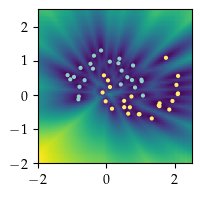

In [95]:
############################### VISUALIZATION #################################
plt.style.use('./aaai25.mplstyle')
plt.tight_layout()
# plt.figure(figsize = (2, 2))

plt.scatter(x_tr[:, 0], x_tr[:, 1], s = 4, c = y_tr, cmap = 'Set3')
# plt.imshow(ntk_std.reshape(N_val, N_val), origin = 'lower', extent = (X_min, X_max, Y_min, Y_max), interpolation = 'lanczos')
plt.imshow(UB.reshape(N_val, N_val), origin = 'lower', extent = (X_min, X_max, X_min, X_max))
# plt.colorbar()

# plt.legend()
# plt.savefig("test.png", dpi=300)
plt.savefig("toy-classification-UB.pdf", format="pdf")
# plt.show()